# Stage 6: Mel-Frequency Cepstral Coefficients (MFCCs)

Stage 5 evaluated classifiers restricted to acoustic-prosodic summary statistics (energy, zero-crossing rate, pitch, two formants, duration) and observed a modest accuracy ceiling, attributed to the feature set capturing the paralinguistic character of an utterance while carrying little information about which words were spoken. This stage tests that diagnosis directly: mel-frequency cepstral coefficients (MFCCs), a substantially fuller representation of the spectral envelope, are added to the same feature vector, and the same classifiers are re-evaluated to determine whether accuracy improves as a result.

In [1]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

DATA_ROOT = "../data/fluent_speech_commands_dataset"
WAV_PATH = f"{DATA_ROOT}/wavs/speakers/2BqVo8kVB2Skwgyb/ac4fca80-447a-11e9-a9a5-5dbec3b8816a.wav"
TRANSCRIPT = "Bring socks"
FRAME_LEN, HOP_LEN = 400, 160  # 25 ms / 10 ms at 16 kHz, matching Stages 0-4
N_MFCC = 13

y, sr = librosa.load(WAV_PATH, sr=None)

## Mel-frequency cepstral coefficients

MFCCs are computed from the magnitude spectrum of each frame in three stages. First, the spectrum is passed through a bank of overlapping triangular filters spaced on the mel scale, a frequency scale approximating human pitch perception (approximately linear below 1 kHz, increasingly compressed above it), collapsing the spectrum into a small number of perceptually-weighted band energies. Second, the logarithm of each filterbank energy is taken; because speech is approximately a source signal filtered by the vocal tract, this multiplicative relationship becomes additive in the log-spectral domain, which the next step exploits. Third, a Discrete Cosine Transform (DCT) is applied across the log filterbank energies, decorrelating them and concentrating the spectral-envelope information into a small number of low-order coefficients, which vary slowly across frequency, while pitch-harmonic detail is pushed into higher-order coefficients. The first 13 coefficients per frame are retained, following common practice.

MFCCs are computed here with `librosa.feature.mfcc`, using the same 25 ms frame length, 10 ms hop, and Hamming window used throughout Stages 0-4, so that the frame count and time alignment match the other per-frame features already computed. The resulting representation is shown below alongside the Stage 3 spectrogram of the same utterance.

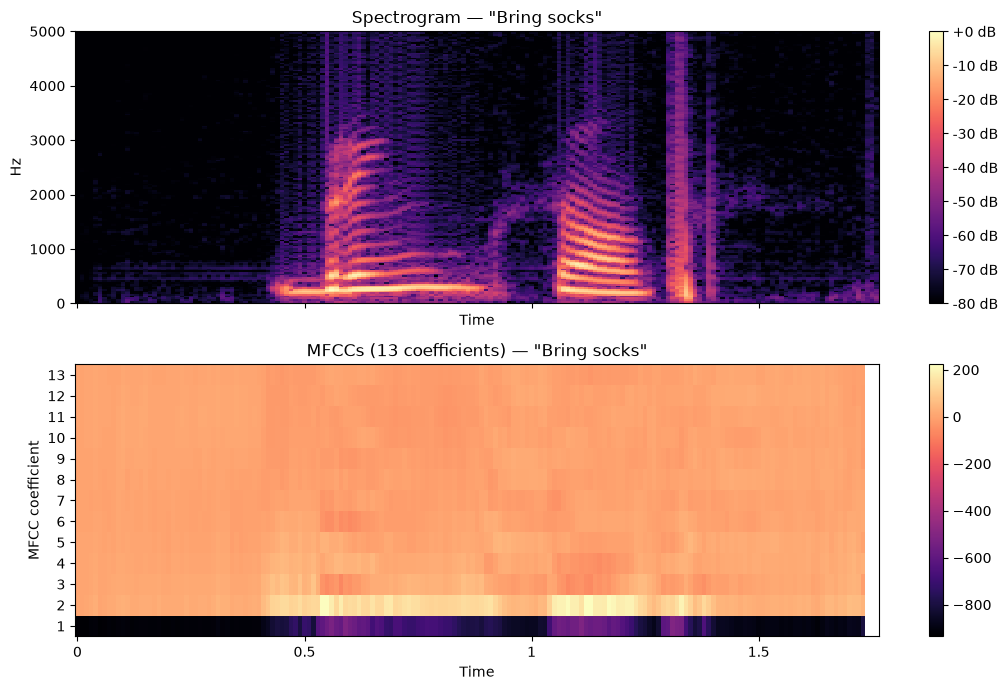

In [2]:
D = librosa.stft(y, n_fft=512, hop_length=HOP_LEN, win_length=FRAME_LEN, window="hamming")
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=FRAME_LEN,
                             hop_length=HOP_LEN, win_length=FRAME_LEN,
                             window="hamming", center=False)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
img0 = librosa.display.specshow(S_db, sr=sr, hop_length=HOP_LEN, x_axis="time", y_axis="linear",
                                 ax=axes[0], cmap="magma", vmin=-80, vmax=0)
axes[0].set_ylim(0, 5000)
axes[0].set_title(f'Spectrogram — "{TRANSCRIPT}"')
fig.colorbar(img0, ax=axes[0], format="%+.0f dB")

img1 = librosa.display.specshow(mfcc, sr=sr, hop_length=HOP_LEN, x_axis="time", ax=axes[1], cmap="magma")
axes[1].set_ylabel("MFCC coefficient")
axes[1].set_yticks(range(N_MFCC))
axes[1].set_yticklabels(range(1, N_MFCC + 1))
axes[1].set_title(f'MFCCs (13 coefficients) — "{TRANSCRIPT}"')
fig.colorbar(img1, ax=axes[1])
fig.tight_layout()
plt.show()

## Reading the MFCC representation

The MFCC representation compresses the several hundred frequency bins of the spectrogram into 13 coefficients per frame, and the two panels are visually very different as a result. The first coefficient (bottom row) has a substantially larger dynamic range than the remaining twelve and dominates the shared color scale: it is markedly lower during the silent and low-energy intervals (the utterance-initial gap and the pause between words) and higher during the voiced and burst regions, closely mirroring the short-time energy pattern established in Stage 1. This is expected, since the first mel-cepstral coefficient is closely related to the overall log-energy of the frame rather than to the shape of the spectral envelope. The remaining coefficients vary far more subtly on this shared scale but still shift detectably between the silent, voiced, and burst regions of the utterance, consistent with them encoding finer spectral-envelope structure rather than overall loudness. Unlike the spectrogram's formant bands, this structure is not readily interpretable by direct inspection, which is the expected trade-off of a representation designed for compactness and decorrelation rather than physical interpretability.

## Full-dataset feature vector

MFCC statistics (mean and standard deviation of each of the 13 coefficients across all frames of the utterance, 26 features) are computed for all 30,043 utterances by `scripts/extract_mfcc_features.py` and merged with the Stage 5 prosodic feature cache on utterance path, reusing the previously-computed energy, zero-crossing-rate, pitch, and formant features rather than recomputing them. Because MFCC computation does not require the pitch estimation or per-frame LPC analysis that dominated Stage 5's extraction cost, this pass completes in under a minute for the full corpus. The resulting feature vector has 36 dimensions: the 10 prosodic features from Stage 5 plus the 26 new MFCC statistics.

In [3]:
features = pd.read_csv(f"{DATA_ROOT}/features_cache_mfcc.csv")
print(f"Total utterances: {len(features)}")
print(f"Feature columns: {features.shape[1]}")
features.groupby("split").size()

Total utterances: 30043
Feature columns: 43


split
test      3793
train    23132
valid     3118
dtype: int64

In [4]:
feature_cols = ["mean_energy_db", "std_energy_db", "mean_zcr", "std_zcr",
                "voiced_fraction", "mean_f0", "std_f0", "mean_f1", "mean_f2", "duration_s"] + \
    [f"mfcc{i}_{stat}" for i in range(1, N_MFCC + 1) for stat in ("mean", "std")]

train_df = features[features["split"] == "train"].dropna(subset=feature_cols)
valid_df = features[features["split"] == "valid"].dropna(subset=feature_cols)
test_df = features[features["split"] == "test"].dropna(subset=feature_cols)

label_encoder = LabelEncoder()
label_encoder.fit(features["intent"])

X_train, y_train = train_df[feature_cols].values, label_encoder.transform(train_df["intent"])
X_valid, y_valid = valid_df[feature_cols].values, label_encoder.transform(valid_df["intent"])
X_test, y_test = test_df[feature_cols].values, label_encoder.transform(test_df["intent"])

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_valid_s = scaler.transform(X_valid)
X_test_s = scaler.transform(X_test)

print(f"Feature vector size: {len(feature_cols)}")
print(f"Train: {X_train_s.shape}, Valid: {X_valid_s.shape}, Test: {X_test_s.shape}")

Feature vector size: 36
Train: (23132, 36), Valid: (3118, 36), Test: (3793, 36)


## Classifiers

The same three classifiers and the same grid-search methodology used in Stage 5 are applied here: a majority-class baseline, a support vector machine with an RBF kernel (grid search over C and gamma), and a multi-layer perceptron (grid search over hidden layer size and L2 regularization strength), each selected by highest validation accuracy, with the test set used only for final reporting. Class weighting is not re-evaluated here, since Stage 5 already established that it does not yield a worthwhile improvement on this classification task; omitting it keeps this stage's comparison isolated to the effect of adding MFCC features.

In [5]:
results = {}

baseline = DummyClassifier(strategy="most_frequent").fit(X_train_s, y_train)
results["Majority baseline"] = {
    "valid_acc": accuracy_score(y_valid, baseline.predict(X_valid_s)),
    "test_acc": accuracy_score(y_test, baseline.predict(X_test_s)),
}

best_svm, best_svm_acc, best_svm_params = None, -1, None
for C in [1, 10, 100]:
    for gamma in ["scale", 0.01, 0.1]:
        m = SVC(kernel="rbf", C=C, gamma=gamma).fit(X_train_s, y_train)
        acc = accuracy_score(y_valid, m.predict(X_valid_s))
        if acc > best_svm_acc:
            best_svm, best_svm_acc, best_svm_params = m, acc, (C, gamma)
svm = best_svm
print(f"Best SVM: C={best_svm_params[0]}, gamma={best_svm_params[1]} "
      f"(support vectors: {svm.n_support_.sum()}/{len(X_train_s)})")
results["SVM (RBF)"] = {
    "valid_acc": best_svm_acc,
    "test_acc": accuracy_score(y_test, svm.predict(X_test_s)),
}

best_mlp, best_mlp_acc, best_mlp_params = None, -1, None
for hidden in [(64,), (128,), (64, 32)]:
    for alpha in [0.0001, 0.001]:
        m = MLPClassifier(hidden_layer_sizes=hidden, alpha=alpha, max_iter=1000, random_state=0).fit(X_train_s, y_train)
        acc = accuracy_score(y_valid, m.predict(X_valid_s))
        if acc > best_mlp_acc:
            best_mlp, best_mlp_acc, best_mlp_params = m, acc, (hidden, alpha)
mlp = best_mlp
print(f"Best MLP: hidden_layer_sizes={best_mlp_params[0]}, alpha={best_mlp_params[1]} "
      f"(converged after {mlp.n_iter_} iterations)")
results["MLP"] = {
    "valid_acc": best_mlp_acc,
    "test_acc": accuracy_score(y_test, mlp.predict(X_test_s)),
}

results_df = pd.DataFrame(results).T
results_df.columns = ["Validation accuracy", "Test accuracy"]
results_df

Best SVM: C=1, gamma=0.01 (support vectors: 22772/23132)


Best MLP: hidden_layer_sizes=(64, 32), alpha=0.001 (converged after 367 iterations)


,Validation accuracy,Test accuracy
Majority baseline,0.101988,0.104403
SVM (RBF),0.222899,0.258107
MLP,0.223861,0.209597


## Confusion matrix

The confusion matrix for the best-performing classifier on the test split is shown below.

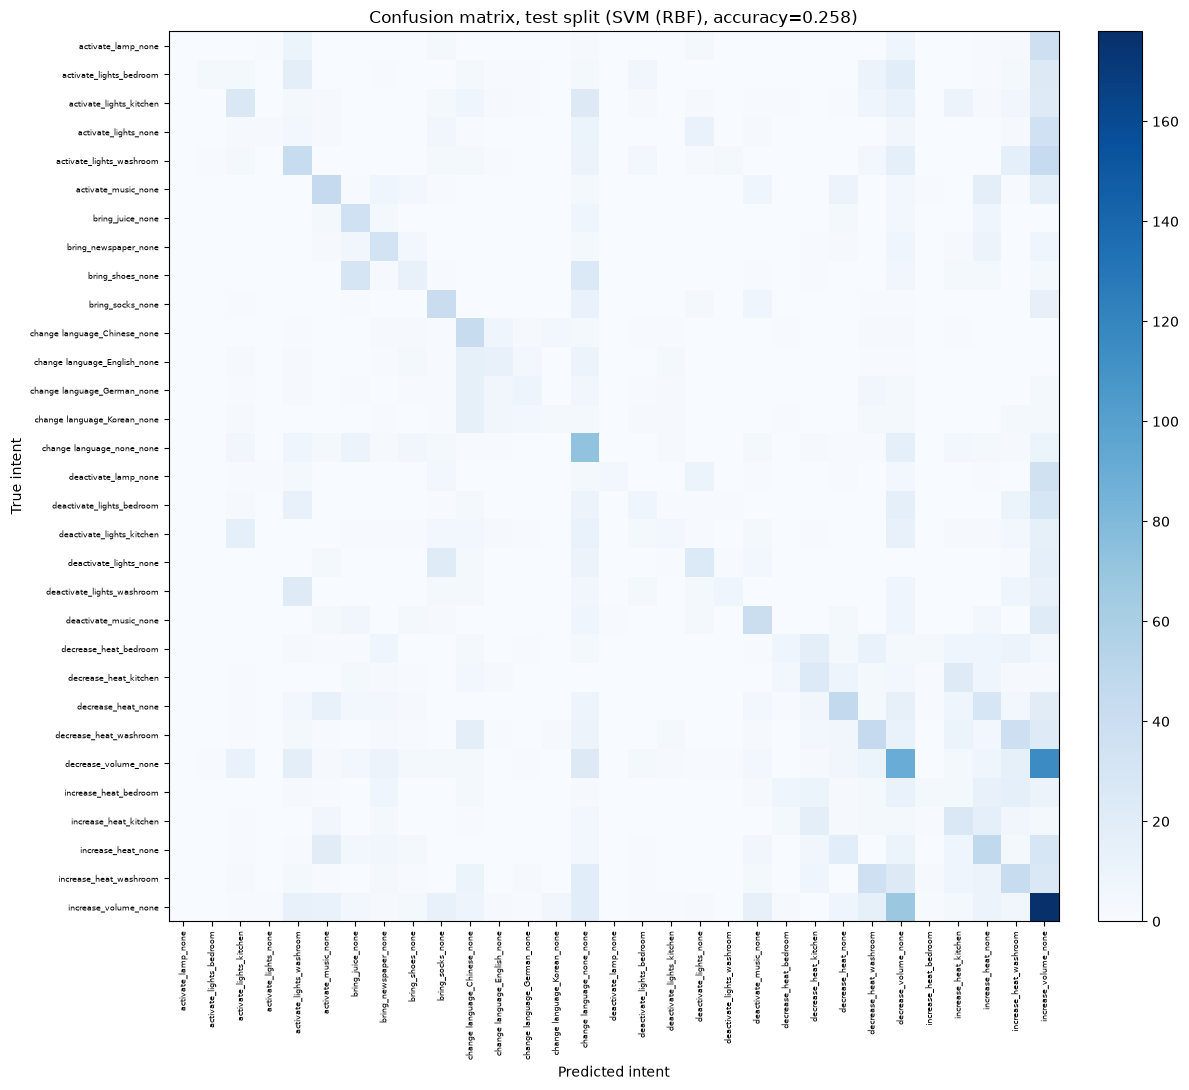

In [6]:
best_name = results_df["Test accuracy"].idxmax()
best_model = {"Majority baseline": baseline, "SVM (RBF)": svm, "MLP": mlp}[best_name]
y_pred = best_model.predict(X_test_s)
cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(label_encoder.classes_)))

fig, ax = plt.subplots(figsize=(12, 11))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(label_encoder.classes_)))
ax.set_yticks(range(len(label_encoder.classes_)))
ax.set_xticklabels(label_encoder.classes_, rotation=90, fontsize=6)
ax.set_yticklabels(label_encoder.classes_, fontsize=6)
ax.set_xlabel("Predicted intent")
ax.set_ylabel("True intent")
best_test_acc = results_df.loc[best_name, "Test accuracy"]
ax.set_title(f"Confusion matrix, test split ({best_name}, accuracy={best_test_acc:.3f})")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## Results

Adding MFCC statistics to the feature vector produces a substantial accuracy improvement for both classifiers, confirming the diagnosis made in Stage 5. The SVM's test accuracy rises from 16.5% (Stage 5, prosodic features only) to 25.8% (Stage 6, prosodic + MFCC features), an increase of 9.3 percentage points, approximately 56% relative to the Stage 5 result. The MLP's test accuracy rises from 14.3% to 21.0%, an increase of 6.6 percentage points, approximately 46% relative. Both increases are far larger than any change observed in Stage 5 from feature-quality refinements within the prosodic feature family (at most 2-3 percentage points) or from classifier hyperparameter tuning (which plateaued around 15-16% regardless of configuration), and are consistent with the diagnosis that the earlier accuracy ceiling reflected missing spectral/phonetic content rather than a tuning limitation.

The best SVM configuration (C=1, gamma=0.01) uses 22,772 of 23,132 training points as support vectors (98.4%), a proportion similar to Stage 5, indicating that the classification problem remains genuinely difficult to separate even with the expanded feature set rather than becoming trivially separable. The best MLP configuration (hidden_layer_sizes=(64, 32), alpha=0.001) converged after 367 of 1000 allowed iterations, well short of the iteration limit.

This result supports the Stage 5 diagnosis without fully resolving the underlying limitation: the feature vector still summarizes each utterance to a single mean/standard deviation pair per coefficient, discarding the order in which sounds occurred within the utterance. The following stage addresses this directly by reintroducing temporal structure into the feature representation.